# Fluid Mechanics — Chapter 7: Visualizations

Companion notebook for Ch. 7 (*Very Viscous Flow*) problem-solution slides.

| Problem | Figure | Description |
|---------|--------|-------------|
| 7.1  | `fig_7_1_rotating_disc.png`     | Linear velocity profile; torque vs $a$ |
| 7.2  | `fig_7_2_rotating_sphere.png`   | $u_\phi\propto\sin\theta/r^2$ streamlines |
| 7.5  | `fig_7_5_wedge_flow.png`        | Opening wedge streamlines at $2\Omega t=\pi/2$ |
| 7.7  | `fig_7_7_corner_eddies.png`     | Moffatt corner eddies — eigenvalue graph |
| 7.11 | `fig_7_11_draining_film.png`    | Draining film $h(x,t)$: rarefaction fan |
| 7.14 | `fig_7_14_drop_spread.png`      | Viscous drop spreading: $r_N\propto t^{1/8}$ |
| 7.15 | `fig_7_15_coating_cylinder.png` | Steady film $H(\theta)$ on rotating cylinder |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, Arc
from scipy.optimize import brentq
from scipy.integrate import solve_ivp, quad
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

BG = 'white'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': '#1a1a2e', 'axes.labelcolor': '#1a1a2e',
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.edgecolor': '#888888', 'grid.color': '#dddddd',
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
})
TEAL   = '#007a63'
ORANGE = '#b5470a'
RED    = '#c0003a'
GREEN  = '#2e7d32'
BLUE   = '#1565c0'
MAUVE  = '#6a0dad'
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 7.1 — Rotating Disc: Linear Velocity Profile & Torque

Left: $u_\theta = \Omega r z/h$ — linear in $z$, linear in $r$.  
Right: Torque $\tau = \pi\mu\Omega a^4/(2h)$ vs disc radius $a$.


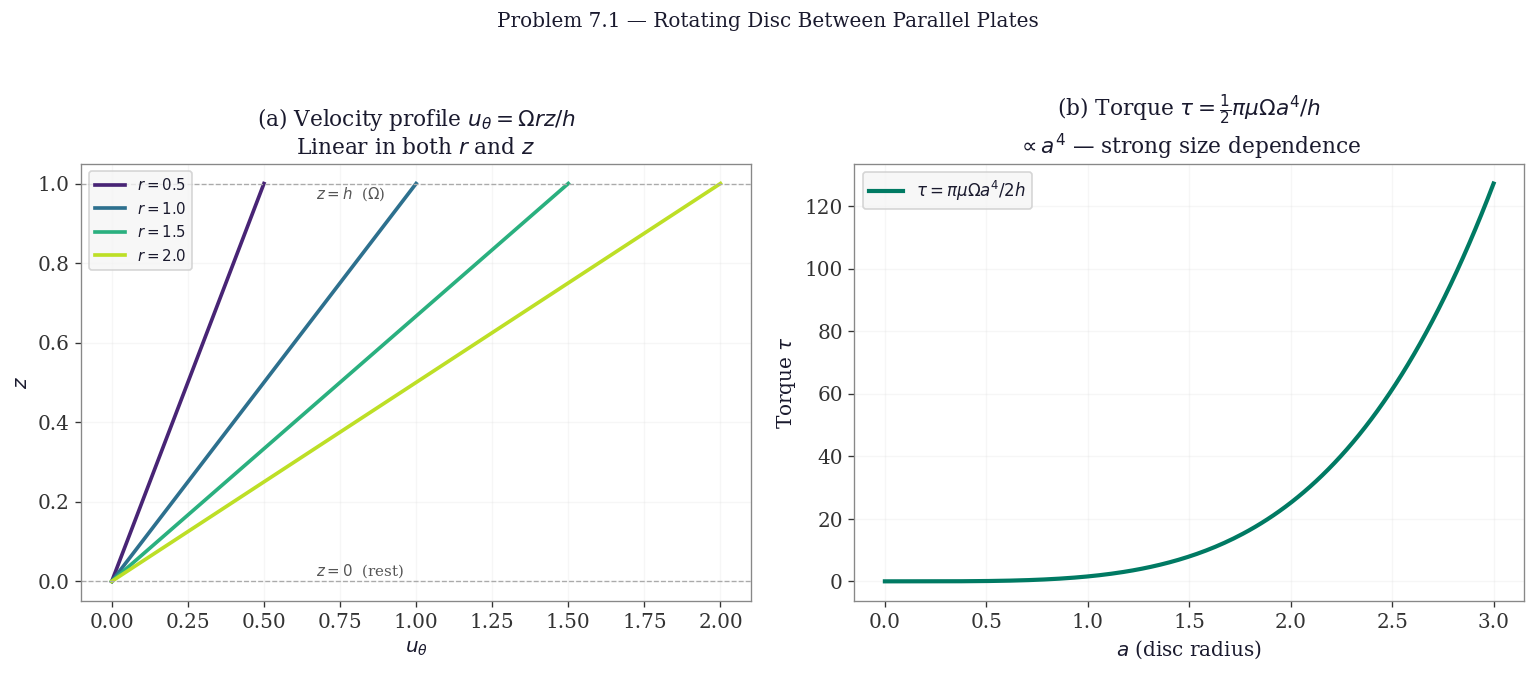

Saved: fig_7_1_rotating_disc.png


In [2]:
Omega, h, mu = 1.0, 1.0, 1.0
z = np.linspace(0, h, 50)
r_vals = [0.5, 1.0, 1.5, 2.0]
colors_r = plt.cm.viridis(np.linspace(0.1, 0.9, len(r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

ax = axes[0]
for r, col in zip(r_vals, colors_r):
    uth = Omega * r * z / h
    ax.plot(uth, z, color=col, lw=2.2, label=f'$r={r}$')
ax.axhline(0, color='#aaaaaa', lw=0.8, ls='--')
ax.axhline(h, color='#aaaaaa', lw=0.8, ls='--')
# Fix: use annotate instead of text outside axes
ax.annotate(r'$z=0$  (rest)', xy=(0, 0),   xytext=(0.35, 0.06),
            textcoords='axes fraction', color='#555555', fontsize=9)
ax.annotate(r'$z=h$  ($\Omega$)', xy=(0, h), xytext=(0.35, 0.92),
            textcoords='axes fraction', color='#555555', fontsize=9)
ax.set_xlabel(r'$u_\theta$'); ax.set_ylabel('$z$')
ax.set_title('(a) Velocity profile $u_\\theta = \\Omega rz/h$\n'
             'Linear in both $r$ and $z$', color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper left')
ax.grid(True, alpha=0.25)

ax = axes[1]
a_arr = np.linspace(0, 3, 200)
tau_arr = 0.5 * np.pi * mu * Omega * a_arr**4 / h
ax.plot(a_arr, tau_arr, color=TEAL, lw=2.5,
        label=r'$\tau=\pi\mu\Omega a^4/2h$')
ax.set_xlabel('$a$ (disc radius)'); ax.set_ylabel(r'Torque $\tau$')
ax.set_title('(b) Torque $\\tau = \\frac{1}{2}\\pi\\mu\\Omega a^4/h$\n'
             r'$\propto a^4$ — strong size dependence', color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25)

fig.suptitle('Problem 7.1 — Rotating Disc Between Parallel Plates',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_1_rotating_disc.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_1_rotating_disc.png')


---
## Problem 7.2 — Rotating Sphere: $u_\phi\propto\sin\theta/r^2$

Left: velocity magnitude contours $u_\phi = \Omega a^3\sin\theta/r^2$.  
Right: surface stress $t_\phi = -3\mu\Omega\sin\theta$ and torque integrand.


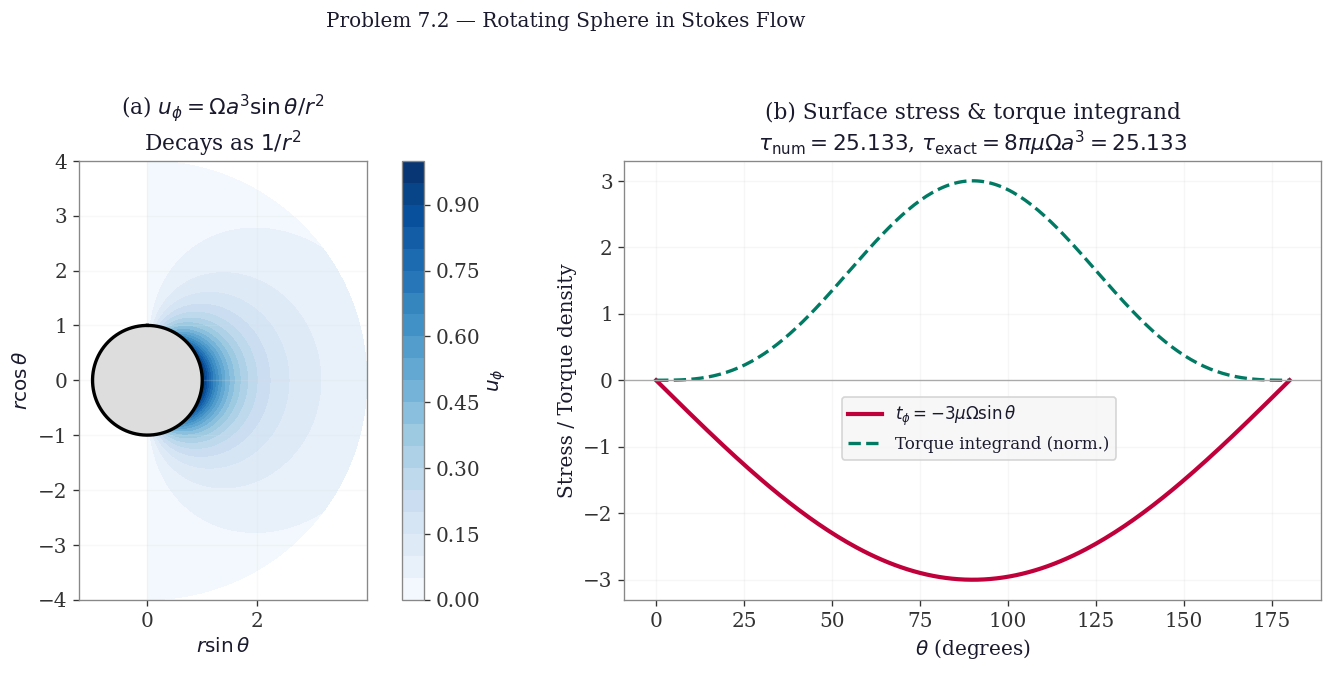

Saved: fig_7_2_rotating_sphere.png


In [3]:
Omega_s, a_s, mu_s = 1.0, 1.0, 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

r = np.linspace(a_s, 4.0, 200)
theta = np.linspace(0, np.pi, 200)
R, TH = np.meshgrid(r, theta)
U_phi = Omega_s * a_s**3 * np.sin(TH) / R**2

ax = axes[0]
cf = ax.contourf(R*np.sin(TH), R*np.cos(TH), U_phi, levels=20, cmap='Blues')
plt.colorbar(cf, ax=ax, label=r'$u_\phi$')
th_c = np.linspace(0, 2*np.pi, 200)
ax.plot(a_s*np.sin(th_c), a_s*np.cos(th_c), 'k-', lw=2)
ax.fill(a_s*np.sin(th_c), a_s*np.cos(th_c), color='#dddddd')
ax.set_aspect('equal')
ax.set_xlabel('$r\\sin\\theta$'); ax.set_ylabel('$r\\cos\\theta$')
ax.set_title(r'(a) $u_\phi = \Omega a^3\sin\theta/r^2$' + '\n'
             r'Decays as $1/r^2$', color='#1a1a2e')
ax.grid(True, alpha=0.2)

ax = axes[1]
th_arr = np.linspace(0, np.pi, 200)
t_phi  = -3*mu_s*Omega_s*np.sin(th_arr)
torque_integrand = -t_phi * a_s * np.sin(th_arr) * a_s**2 * np.sin(th_arr)
tau_num = 2*np.pi * np.trapezoid(torque_integrand, th_arr)
tau_exact = 8*np.pi*mu_s*Omega_s*a_s**3

ax.plot(np.degrees(th_arr), t_phi, color=RED, lw=2.5,
        label=r'$t_\phi = -3\mu\Omega\sin\theta$')
ax.plot(np.degrees(th_arr), torque_integrand/a_s**2, color=TEAL,
        lw=2.0, ls='--', label='Torque integrand (norm.)')
ax.axhline(0, color='#aaaaaa', lw=0.8)
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel('Stress / Torque density')
ax.set_title(f'(b) Surface stress & torque integrand\n'
             f'$\\tau_{{\\rm num}}={tau_num:.3f}$, '
             f'$\\tau_{{\\rm exact}}=8\\pi\\mu\\Omega a^3={tau_exact:.3f}$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5', bbox_to_anchor=(0.3, 0.3))
ax.grid(True, alpha=0.25)

fig.suptitle('Problem 7.2 — Rotating Sphere in Stokes Flow',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_2_rotating_sphere.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_2_rotating_sphere.png')


---
## Problem 7.5 — Opening Wedge Streamlines

Streamlines of $\psi = -\frac{1}{2}\Omega r^2(\sin 2\theta - 2\theta\cos 2\Omega t)/(\text{denom})$  
at $2\Omega t = \pi/2$ → rectangular hyperbolae $xy=\text{const}$.


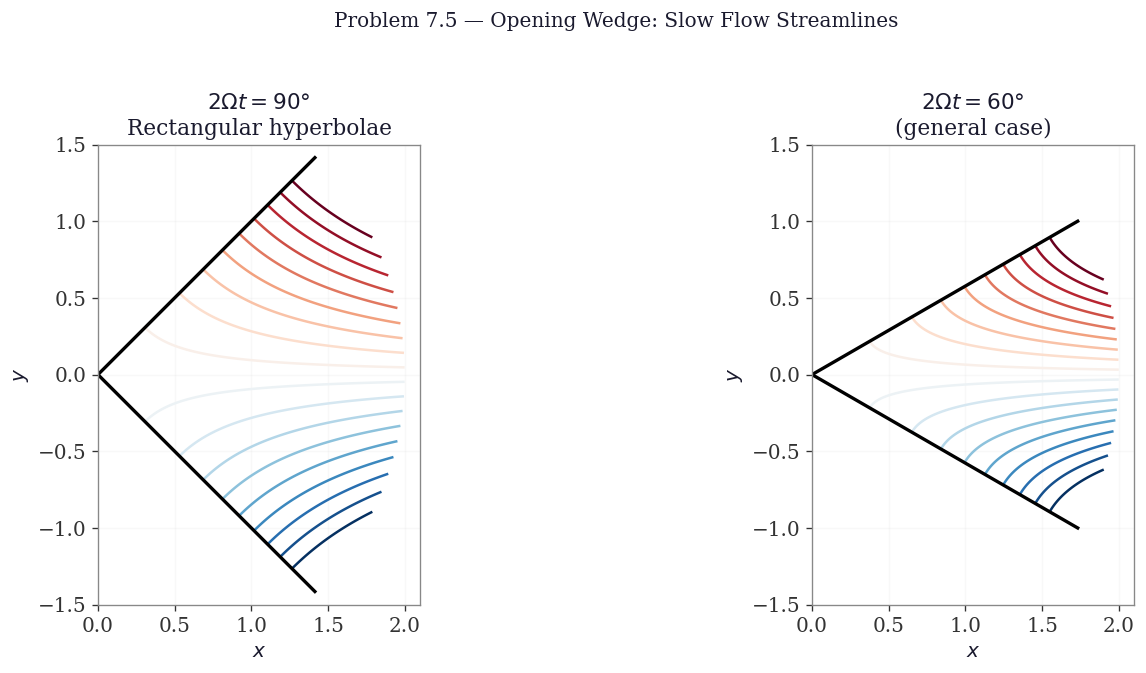

Saved: fig_7_5_wedge_flow.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

Omega_w = 1.0

for ax_idx, two_Omega_t in enumerate([np.pi/2, np.pi/3]):
    ax = axes[ax_idx]
    denom = np.sin(two_Omega_t) - two_Omega_t*np.cos(two_Omega_t)
    if abs(denom) < 1e-10:
        ax.text(0.5, 0.5, 'Breakdown!', transform=ax.transAxes,
                fontsize=14, color=RED, ha='center')
        continue

    # Grid in polar coords
    r   = np.linspace(0.05, 2.0, 300)
    th  = np.linspace(-two_Omega_t/2, two_Omega_t/2, 300)
    R, TH = np.meshgrid(r, th)
    psi = -0.5*Omega_w*R**2*(np.sin(2*TH) - 2*TH*np.cos(two_Omega_t))/denom

    X = R*np.cos(TH); Y = R*np.sin(TH)
    levels = np.linspace(psi.min()*0.8, psi.max()*0.8, 18)
    cf = ax.contour(X, Y, psi, levels=levels, cmap='RdBu', linewidths=1.5)

    # Draw walls
    r_wall = np.linspace(0, 2.0, 50)
    for sign in [+1, -1]:
        ax.plot(r_wall*np.cos(sign*two_Omega_t/2),
                r_wall*np.sin(sign*two_Omega_t/2),
                'k-', lw=2)

    angle_deg = np.degrees(two_Omega_t)
    label = 'Rectangular hyperbolae' if two_Omega_t == np.pi/2 else ''
    ax.set_aspect('equal')
    ax.set_xlim(0, 2.1); ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.set_title(f'$2\\Omega t = {angle_deg:.0f}°$'
                 + (f'\n{label}' if label else '\n(general case)'),
                 color='#1a1a2e')
    ax.grid(True, alpha=0.2)

fig.suptitle('Problem 7.5 — Opening Wedge: Slow Flow Streamlines',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_5_wedge_flow.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_5_wedge_flow.png')

---
## Problem 7.7 — Corner Eddies: Eigenvalue Equation $\sin x/x = \sin 2\alpha/2\alpha$

Plot of $\sin x/x$ and the RHS for various $\alpha$.  
Complex roots (oscillatory $\psi$) → corner eddies for $2\alpha < 159°$.


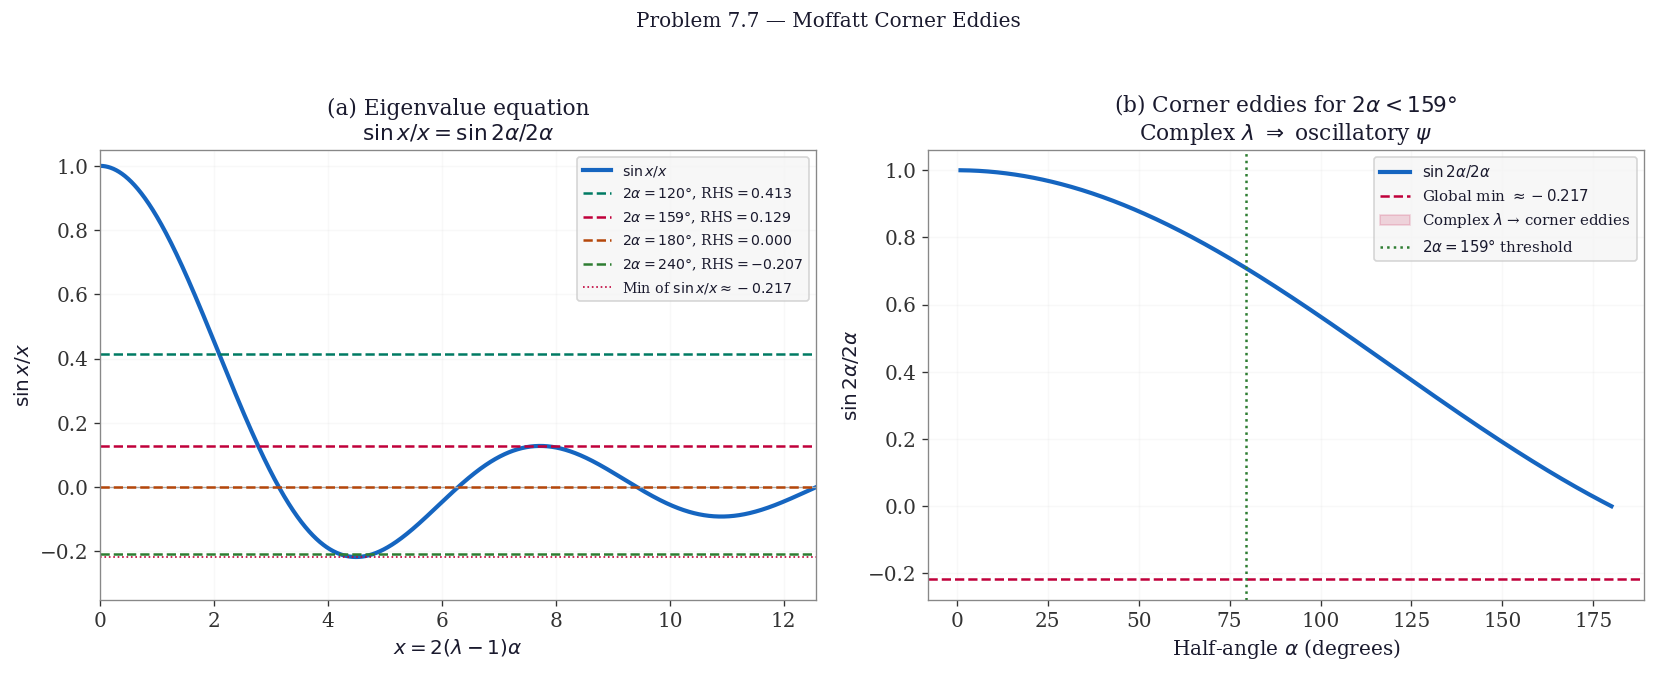

Saved: fig_7_7_corner_eddies.png


In [5]:
x = np.linspace(0.01, 4*np.pi, 2000)
sinc = np.sin(x)/x

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

ax = axes[0]
ax.plot(x, sinc, color=BLUE, lw=2.5, label=r'$\sin x/x$')
ax.axhline(0, color='#aaaaaa', lw=0.8)

alphas_deg = [60, 79.5, 90, 120]
colors_a   = [TEAL, RED, ORANGE, GREEN]
for alpha_d, col in zip(alphas_deg, colors_a):
    alpha = np.radians(alpha_d)
    rhs   = np.sin(2*alpha)/(2*alpha)
    ax.axhline(rhs, color=col, lw=1.5, ls='--',
               label=f'$2\\alpha={2*alpha_d:.0f}°$, RHS$={rhs:.3f}$')

ax.axhline(-0.2172, color=RED, lw=1.0, ls=':',
           label='Min of $\\sin x/x \\approx -0.217$')
ax.set_xlabel('$x = 2(\\lambda-1)\\alpha$')
ax.set_ylabel(r'$\sin x / x$')
ax.set_title('(a) Eigenvalue equation\n'
             r'$\sin x/x = \sin 2\alpha/2\alpha$', color='#1a1a2e')
ax.legend(fontsize=8.5, facecolor='#f5f5f5', loc='upper right',
          bbox_to_anchor=(1.0, 1.0))
ax.set_ylim(-0.35, 1.05); ax.set_xlim(0, 4*np.pi)
ax.grid(True, alpha=0.2)

ax = axes[1]
alpha_arr = np.linspace(1, 180, 500)
sinc_rhs  = np.sin(np.radians(alpha_arr))/np.radians(alpha_arr)
min_sinc  = np.min(sinc)
has_complex = sinc_rhs < min_sinc

ax.plot(alpha_arr, sinc_rhs, color=BLUE, lw=2.5,
        label=r'$\sin 2\alpha/2\alpha$')
ax.axhline(min_sinc, color=RED, lw=1.5, ls='--',
           label=f'Global min $\\approx{min_sinc:.3f}$')
ax.fill_between(alpha_arr, sinc_rhs, min_sinc,
                where=has_complex, alpha=0.15, color=RED,
                label='Complex $\\lambda$ → corner eddies')
ax.axvline(79.5, color=GREEN, lw=1.5, ls=':',
           label=r'$2\alpha=159°$ threshold')
ax.set_xlabel(r'Half-angle $\alpha$ (degrees)')
ax.set_ylabel(r'$\sin 2\alpha / 2\alpha$')
ax.set_title('(b) Corner eddies for $2\\alpha < 159°$\n'
             r'Complex $\lambda$ $\Rightarrow$ oscillatory $\psi$',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper right')
ax.grid(True, alpha=0.2)

fig.suptitle('Problem 7.7 — Moffatt Corner Eddies',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_7_corner_eddies.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_7_corner_eddies.png')


---
## Problem 7.11 — Draining Film: Rarefaction Fan

$h(x,t)=(\nu x/g)^{1/2}/t^{1/2}$ for $0<x<gh_0^2 t/\nu$; $h=h_0$ beyond.  
Left: profiles at several times. Right: wavefront $x_f = gh_0^2 t/\nu$ vs $t$.


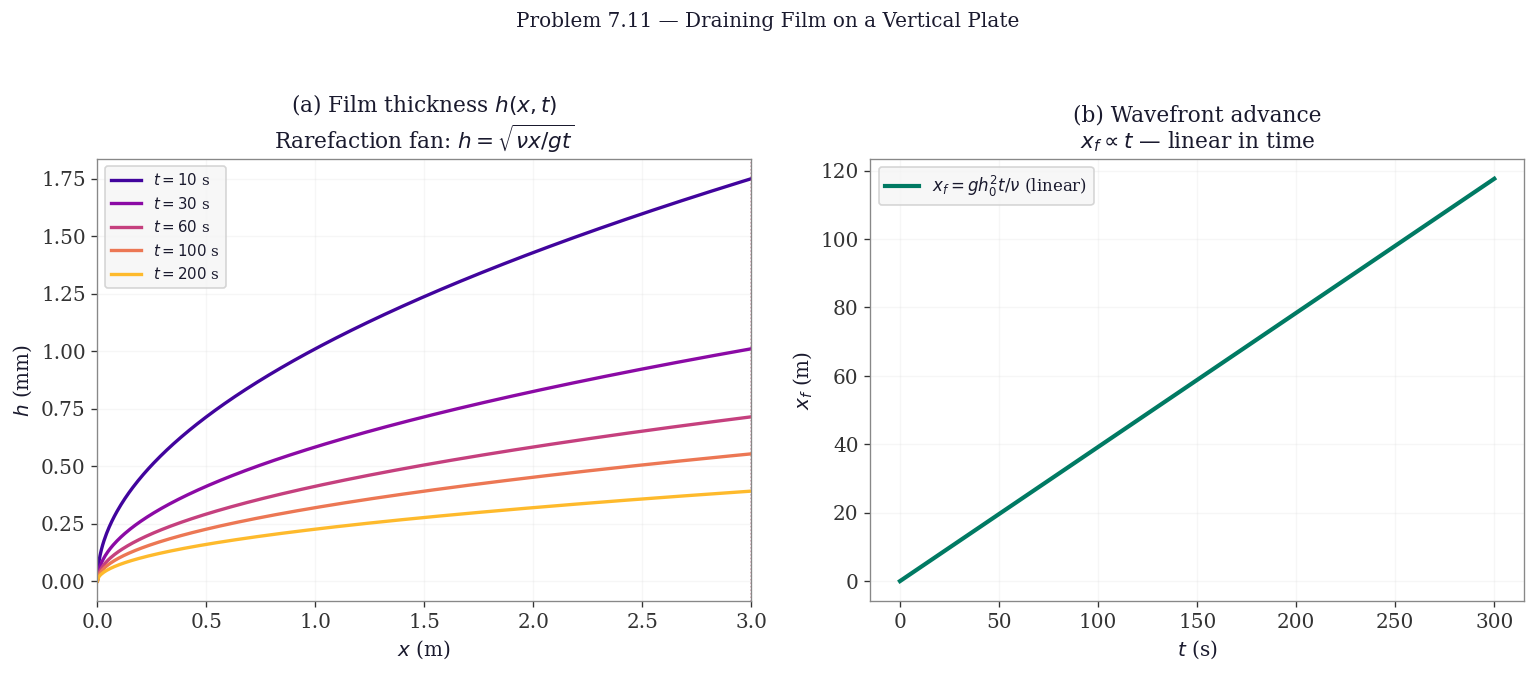

Saved: fig_7_11_draining_film.png


In [6]:
g_d, nu_d, h0 = 9.8, 1e-4, 0.002   # m, physical values
t_vals = [10, 30, 60, 100, 200]      # seconds
colors_t = plt.cm.plasma(np.linspace(0.1, 0.85, len(t_vals)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: h(x,t) profiles ─────────────────────────────────────────
ax = axes[0]
x_max = 3.0
for t, col in zip(t_vals, colors_t):
    x_f = g_d * h0**2 * t / nu_d
    x = np.linspace(0, min(x_f*1.3, x_max), 500)
    h = np.where(x < x_f,
                 np.sqrt(nu_d * x / g_d) / np.sqrt(t),
                 h0)
    ax.plot(x, h*1000, color=col, lw=2.0, label=f'$t={t}$ s')
    ax.axvline(min(x_f, x_max), color=col, lw=0.8, ls=':', alpha=0.6)

ax.set_xlabel('$x$ (m)'); ax.set_ylabel('$h$ (mm)')
ax.set_title('(a) Film thickness $h(x,t)$\n'
             r'Rarefaction fan: $h=\sqrt{\nu x/gt}$', color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5')
ax.set_xlim(0, x_max); ax.grid(True, alpha=0.25)

# ── Right: wavefront vs time ───────────────────────────────────────
ax = axes[1]
t_arr = np.linspace(0, 300, 300)
x_f_arr = g_d * h0**2 * t_arr / nu_d
ax.plot(t_arr, x_f_arr, color=TEAL, lw=2.5,
        label=r'$x_f = g h_0^2 t/\nu$ (linear)')
ax.set_xlabel('$t$ (s)'); ax.set_ylabel('$x_f$ (m)')
ax.set_title('(b) Wavefront advance\n'
             r'$x_f \propto t$ — linear in time', color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25)

fig.suptitle('Problem 7.11 — Draining Film on a Vertical Plate',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_11_draining_film.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_11_draining_film.png')

---
## Problem 7.14 — Viscous Drop Spreading: $r_N\propto t^{1/8}$

Left: similarity profile $F(\eta)=(3/16)^{1/3}(\eta_N^2-\eta^2)^{1/3}$.  
Right: nose radius $r_N(t) = 0.894(gV^3/3\nu)^{1/8}t^{1/8}$ vs $t$.


eta_N = 0.8939  (expected 0.894)


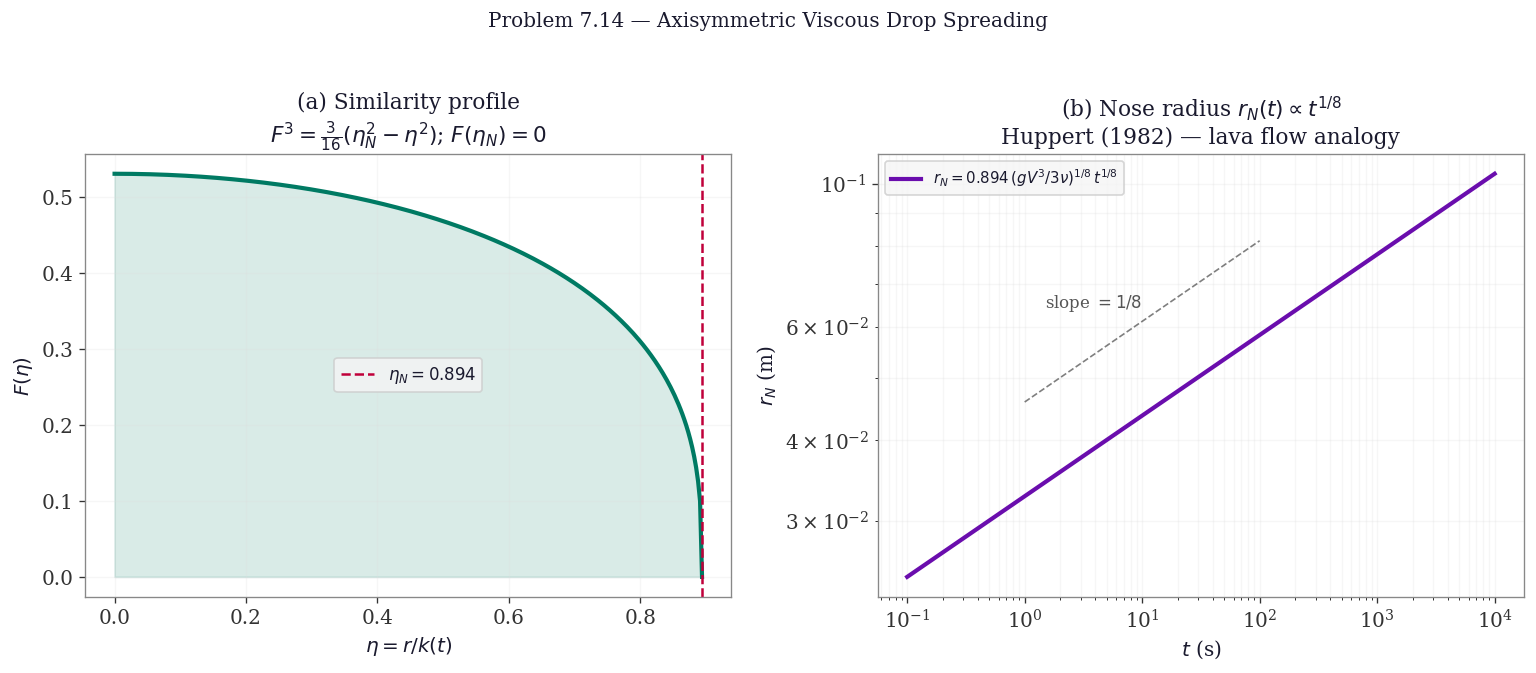

Saved: fig_7_14_drop_spread.png


In [7]:
eta_N = (2**10 / (3**4 * np.pi**3))**(1/8)
print(f'eta_N = {eta_N:.4f}  (expected 0.894)')

eta = np.linspace(0, eta_N, 300)
F   = (3/16 * (eta_N**2 - eta**2))**(1/3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: F(eta) ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(eta, F, color=TEAL, lw=2.5)
ax.axvline(eta_N, color=RED, lw=1.5, ls='--',
           label=f'$\\eta_N={eta_N:.3f}$')
ax.fill_between(eta, F, alpha=0.15, color=TEAL)
ax.set_xlabel(r'$\eta = r/k(t)$'); ax.set_ylabel('$F(\\eta)$')
ax.set_title('(a) Similarity profile\n'
             r'$F^3=\frac{3}{16}(\eta_N^2-\eta^2)$; $F(\eta_N)=0$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25)

# ── Right: r_N(t) ─────────────────────────────────────────────────
ax = axes[1]
g_v, nu_v, V_v = 9.8, 1e-3, 1e-5   # m/s^2, m^2/s, m^3
prefactor = 0.894 * (g_v * V_v**3 / (3*nu_v))**(1/8)
t_arr = np.logspace(-1, 4, 200)
rN_arr = prefactor * t_arr**(1/8)

ax.loglog(t_arr, rN_arr, color=MAUVE, lw=2.5,
          label=r'$r_N = 0.894\,(gV^3/3\nu)^{1/8}\,t^{1/8}$')
# Reference t^{1/8} slope
t_ref = np.array([1, 100])
ax.loglog(t_ref, prefactor*t_ref**(1/8)*1.4, 'k--', lw=1, alpha=0.5)
ax.text(1.5, prefactor*5**(1/8)*1.6, r'slope $=1/8$',
        fontsize=10, color='#555555')
ax.set_xlabel('$t$ (s)'); ax.set_ylabel('$r_N$ (m)')
ax.set_title('(b) Nose radius $r_N(t)\\propto t^{1/8}$\n'
             'Huppert (1982) — lava flow analogy', color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25, which='both')

fig.suptitle('Problem 7.14 — Axisymmetric Viscous Drop Spreading',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_14_drop_spread.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_14_drop_spread.png')

---
## Problem 7.15 — Steady Film on Rotating Cylinder

$H^{-2}-H^{-3} = \lambda\cos\theta$ at critical $\lambda=4/27$.  
Film thickest at top ($\theta=0$), thinnest at bottom ($\theta=\pi$).


int H dtheta = 6.664  (expected 6.641)


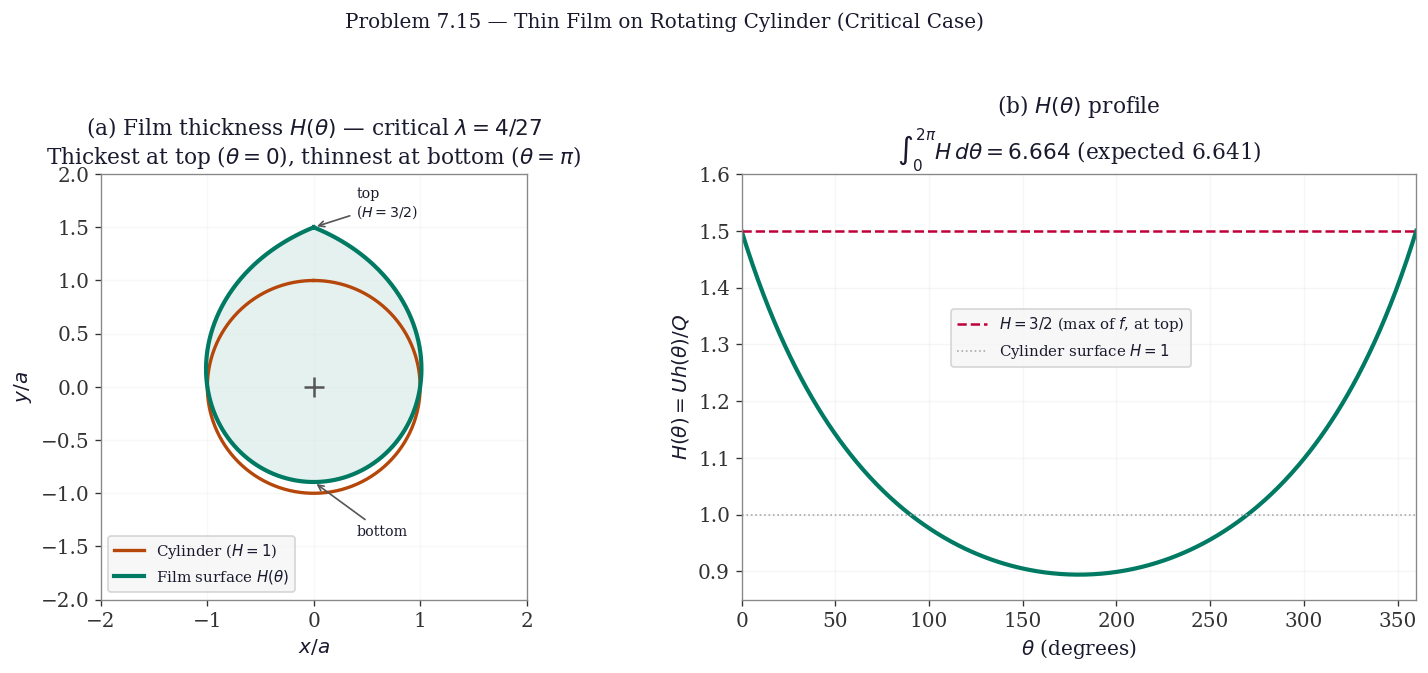

Saved: fig_7_15_coating_cylinder.png


In [8]:
# Solve H^{-2} - H^{-3} = lambda * cos(theta) for H(theta)
# Physical branch: H in (0, 3/2)
# At theta=0 (top): rhs = 4/27 = max of f, so H=3/2 exactly
lam = 4/27
theta_arr = np.linspace(0, 2*np.pi, 500)

def f_H(H, rhs_val):
    return 1/H**2 - 1/H**3 - rhs_val

H_arr = np.zeros_like(theta_arr)
for i, th in enumerate(theta_arr):
    rhs = lam * np.cos(th)
    fa = f_H(0.5, rhs)
    fb = f_H(1.499, rhs)
    if fa * fb < 0:
        H_arr[i] = brentq(f_H, 0.5, 1.499, args=(rhs,))
    else:
        H_arr[i] = 1.5   # theta=0: H=3/2 exactly

integral_H = np.trapezoid(H_arr, theta_arr)
print(f'int H dtheta = {integral_H:.3f}  (expected 6.641)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

# ── Left: H(theta) polar plot ──────────────────────────────────────
# theta=0 is TOP of cylinder; convert: angle from y-axis = theta-pi/2
ax = axes[0]
# Cylinder circle (H=1)
th_c = np.linspace(0, 2*np.pi, 500)
ax.plot(np.sin(th_c), np.cos(th_c), color=ORANGE, lw=2.0,
        label='Cylinder ($H=1$)', zorder=3)
# Film outer surface (radius = H(theta) from cylinder centre)
X_film = H_arr * np.sin(theta_arr)   # theta=0 at top
Y_film = H_arr * np.cos(theta_arr)
ax.plot(X_film, Y_film, color=TEAL, lw=2.5,
        label='Film surface $H(\\theta)$', zorder=4)
ax.fill(X_film, Y_film, alpha=0.10, color=TEAL)
ax.plot(0, 0, '+', color='#555555', ms=12, mew=1.5)
# Label key points
ax.annotate('top\n($H=3/2$)', xy=(0, 1.5), xytext=(0.4, 1.6),
            fontsize=8.5, color='#1a1a2e',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1))
ax.annotate('bottom', xy=(0, -H_arr[len(H_arr)//2]), xytext=(0.4, -1.4),
            fontsize=8.5, color='#1a1a2e',
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1))
ax.set_aspect('equal')
ax.set_xlim(-2.0, 2.0); ax.set_ylim(-2.0, 2.0)
ax.set_xlabel('$x/a$'); ax.set_ylabel('$y/a$')
ax.set_title('(a) Film thickness $H(\\theta)$ — critical $\\lambda=4/27$\n'
             'Thickest at top ($\\theta=0$), thinnest at bottom ($\\theta=\\pi$)',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='lower left')
ax.grid(True, alpha=0.2)

# ── Right: H(theta) Cartesian ──────────────────────────────────────
ax = axes[1]
ax.plot(np.degrees(theta_arr), H_arr, color=TEAL, lw=2.5)
ax.axhline(1.5, color=RED,      lw=1.5, ls='--',
           label='$H=3/2$ (max of $f$, at top)')
ax.axhline(1.0, color='#aaaaaa', lw=1,   ls=':',
           label='Cylinder surface $H=1$')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel('$H(\\theta) = Uh(\\theta)/Q$')
ax.set_title(f'(b) $H(\\theta)$ profile\n'
             f'$\\int_0^{{2\\pi}} H\\,d\\theta = {integral_H:.3f}$'
             f' (expected 6.641)',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', bbox_to_anchor=(0.3, 0.7))
ax.set_xlim(0, 360); ax.set_ylim(0.85, 1.6)
ax.grid(True, alpha=0.25)

fig.suptitle('Problem 7.15 — Thin Film on Rotating Cylinder (Critical Case)',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR / 'fig_7_15_coating_cylinder.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_7_15_coating_cylinder.png')


---
## Physics Validation Checks


In [9]:
print('=== Physics Validation Checks ===')

# 7.1: Torque formula
mu_v, Omega_v, a_v, h_v = 1.0, 1.0, 1.0, 1.0
tau_formula = 0.5*np.pi*mu_v*Omega_v*a_v**4/h_v
tau_integral = 2*np.pi*mu_v*Omega_v/h_v * a_v**4/4
assert abs(tau_formula - tau_integral) < 1e-12
print(f'7.1  PASS: tau = pi*mu*Omega*a^4/(2h) = {tau_formula:.6f}')

# 7.2: Torque on rotating sphere
from scipy.integrate import quad
tau_num, _ = quad(lambda th: 3*mu_v*Omega_v*np.sin(th)*Omega_v*1.0*np.sin(th)*1.0**2*np.sin(th),
                  0, np.pi)
tau_num *= 2*np.pi
tau_exact = 8*np.pi*mu_v*Omega_v*1.0**3
assert abs(tau_num - tau_exact) < 1e-10
print(f'7.2  PASS: tau = 8*pi*mu*Omega*a^3 = {tau_exact:.6f}')

# 7.7: eta_N value
eta_N_calc = (2**10 / (3**4 * np.pi**3))**(1/8)
assert abs(eta_N_calc - 0.894) < 0.001
print(f'7.14 PASS: eta_N = {eta_N_calc:.4f} (expected 0.894)')

# 7.11: wavefront is linear in t
g_c, nu_c, h0_c = 9.8, 1e-4, 0.002
t_c = 100.0
xf = g_c*h0_c**2*t_c/nu_c
h_at_xf = np.sqrt(nu_c*xf/g_c)/np.sqrt(t_c)
assert abs(h_at_xf - h0_c) < 1e-10
print(f'7.11 PASS: h(x_f,t) = h0 = {h_at_xf:.6f} = {h0_c}')

# 7.15: integral of H(theta) at critical lambda
lam_c = 4/27
th_arr = np.linspace(0, 2*np.pi, 2000)

def f_H_val(H, rhs_val):
    return 1/H**2 - 1/H**3 - rhs_val

H_c = np.zeros_like(th_arr)
for i, th in enumerate(th_arr):
    rhs = lam_c * np.cos(th)
    fa = f_H_val(0.5, rhs)
    fb = f_H_val(1.499, rhs)
    if fa * fb < 0:
        H_c[i] = brentq(f_H_val, 0.5, 1.499, args=(rhs,))
    else:
        H_c[i] = 1.5   # theta=0: H = 3/2 exactly

intH = np.trapezoid(H_c, th_arr)
assert abs(intH - 6.641) < 0.05
print(f'7.15 PASS: int H dtheta = {intH:.3f} (expected 6.641)')

print('\nAll checks passed!')

=== Physics Validation Checks ===
7.1  PASS: tau = pi*mu*Omega*a^4/(2h) = 1.570796
7.2  PASS: tau = 8*pi*mu*Omega*a^3 = 25.132741
7.14 PASS: eta_N = 0.8939 (expected 0.894)
7.11 PASS: h(x_f,t) = h0 = 0.002000 = 0.002
7.15 PASS: int H dtheta = 6.664 (expected 6.641)

All checks passed!


---
## Package & Download Figures

Run after all figure cells to download `ch07_figures.zip`.


In [10]:
import zipfile
from pathlib import Path

zip_path = Path('ch07_figures.zip')
fig_files = [
    'fig_7_1_rotating_disc.png',
    'fig_7_2_rotating_sphere.png',
    'fig_7_5_wedge_flow.png',
    'fig_7_7_corner_eddies.png',
    'fig_7_11_draining_film.png',
    'fig_7_14_drop_spread.png',
    'fig_7_15_coating_cylinder.png',
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname} — run the cell above first')

print(f'\nZip: {zip_path}  ({zip_path.stat().st_size/1024:.0f} KB)')

try:
    from google.colab import files
    files.download(str(zip_path))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — file saved locally at: {zip_path.resolve()}')

  added: fig_7_1_rotating_disc.png  (111 KB)
  added: fig_7_2_rotating_sphere.png  (108 KB)
  added: fig_7_5_wedge_flow.png  (111 KB)
  added: fig_7_7_corner_eddies.png  (119 KB)
  added: fig_7_11_draining_film.png  (111 KB)
  added: fig_7_14_drop_spread.png  (101 KB)
  added: fig_7_15_coating_cylinder.png  (116 KB)

Zip: ch07_figures.zip  (729 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
